In [179]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

In [180]:
img = cv2.imread("11.jpg")

cv2.imshow("orig", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [181]:
blur = cv2.GaussianBlur(img, (5, 5), 0)
cv2.imshow("blur", blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [182]:
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
cv2.imshow("gray", gray)
cv2.waitKey()
cv2.destroyAllWindows()

In [183]:
_, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

cv2.imshow("binary", bw)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [184]:
# Finding the contours

contours, hierarchy = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Found : {len(contours)} ")

Found : 15 


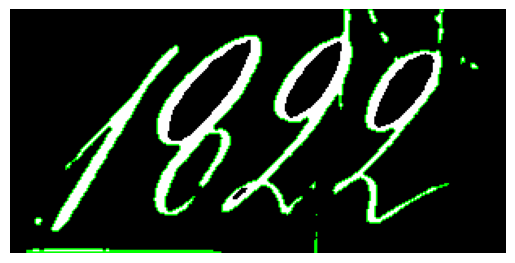

In [185]:
preview = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)

cv2.drawContours(preview, contours, -1, (0, 255, 0), 1)
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [186]:
filtered_contours = []

for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)
    if area > 40 and 10 < w < 80:
        filtered_contours.append(c)

filtered_contours = sorted(filtered_contours, key=cv2.contourArea, reverse=True)
boxes = [cv2.boundingRect(c) for c in filtered_contours]

# sort by x-coordinate (left to right)
boxes_sorted = sorted(boxes, key=lambda b: b[0])

print("Kept", len(filtered_contours), "contours after filtering")

Kept 3 contours after filtering


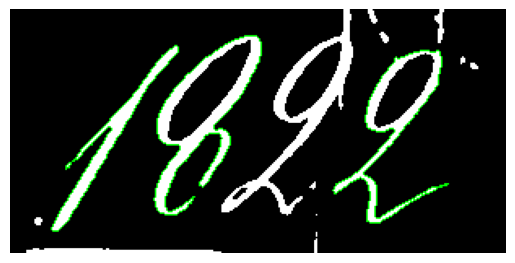

In [187]:
preview_filtered = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)
cv2.drawContours(preview_filtered, filtered_contours, -1, (0, 255, 0), 1)

plt.imshow(cv2.cvtColor(preview_filtered, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

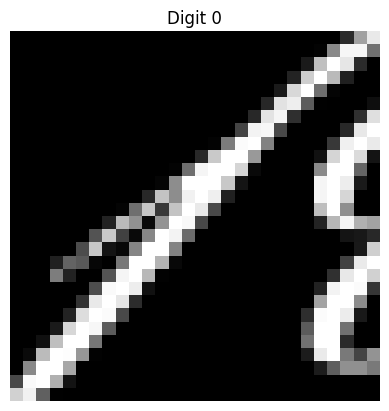

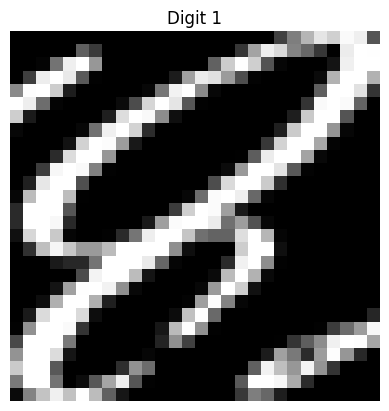

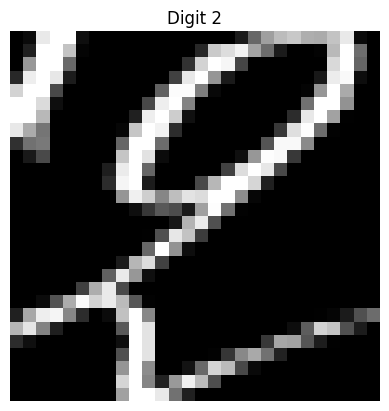

In [ ]:
digit_images = []

for (x, y, w, h) in boxes_sorted:
    digit = bw[y:y+h, x:x+w] 
    resized = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA)
    digit_images.append(resized)

for i, d in enumerate(digit_images):
    plt.imshow(d, cmap="gray")
    plt.title(f"Digit {i}")
    plt.axis("off")
    plt.show()


In [189]:
for i, d in enumerate(digit_images):

    resized = cv2.bitwise_not(d)
    filename = f"./found_digits/digit_{i}.png"
    cv2.imwrite(filename, resized)

    print(f"Saved {filename}")

Saved ./found_digits/digit_0.png
Saved ./found_digits/digit_1.png
Saved ./found_digits/digit_2.png
